In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# <b><font color='teal'>Анализ данных сервиса такси</font></b>

Датасет: ncr_ride_bookings.csv. <br>
Этот набор данных содержит подробные сведения о работе сервиса совместных поездок Uber за 2024 год.<br>
<i>Описание данных:</i><br>
- Date - Дата бронирования
- Time - Время бронирования
- Booking ID - Уникальный идентификатор для каждого бронирования поездки.
- Booking Status - Статус бронирования (Завершено, Отменено клиентом, Отменено водителем и т. д.)
- Customer ID - Уникальный идентификатор для клиентов
- Vehicle Type - Тип транспортного средства (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)
- Pickup Location - Место начала поездки
- Drop Location - Место назначения поездки
- Avg VTAT - Среднее время, необходимое водителю для прибытия в место посадки (в минутах)
- Avg CTAT - Средняя продолжительность поездки от места отправления до места назначения (в минутах)
- Cancelled Rides by Customer - флаг отмены, инициированной клиентом
- Reason for cancelling by Customer - Причина отмены заказа клиентом
- Cancelled Rides by Driver - флаг отмены, инициированной водителем
- Driver Cancellation Reason - Причина отмены поездки водителем
- Incomplete Rides - Флаг незавершенной поездки
- Incomplete Rides Reason - Причина незавершенных поездок
- Booking Value - Общая сумма стоимости поездки
- Ride Distance - Пройденное расстояние за поездку (в км)
- Driver Ratings - Оценка, выставленная водителю (по шкале от 1 до 5)
- Customer Rating - Оценка, выставленная покупателем (по шкале от 1 до 5)
- Payment Method - Способ оплаты (UPI, наличные, кредитная карта, Uber Wallet, дебетовая карта)

In [33]:
# Сделать анализ и понять от чего зависит стоимость поездки в Uber

# Условие Booking Status	=  Completed
# Сначала проверка одного фактора дистанции.
# Потом типа авто.
# Потом времени суток.


df_uber = pd.read_csv('ncr_ride_bookings.csv')
display(df_uber)

df_uber.describe()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


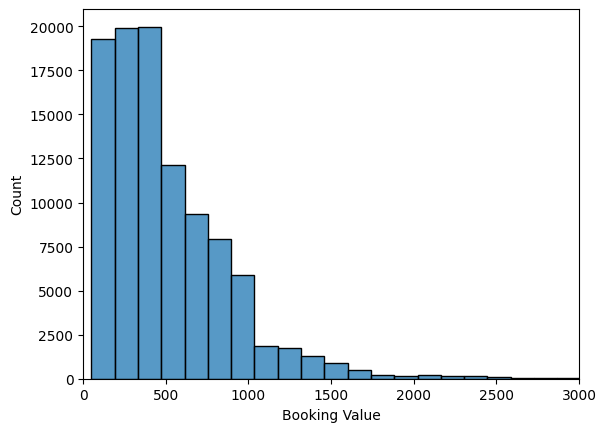

In [12]:
sns.histplot(data=df_uber, x="Booking Value", bins=30)
plt.xlim(0, 3000)
plt.show()

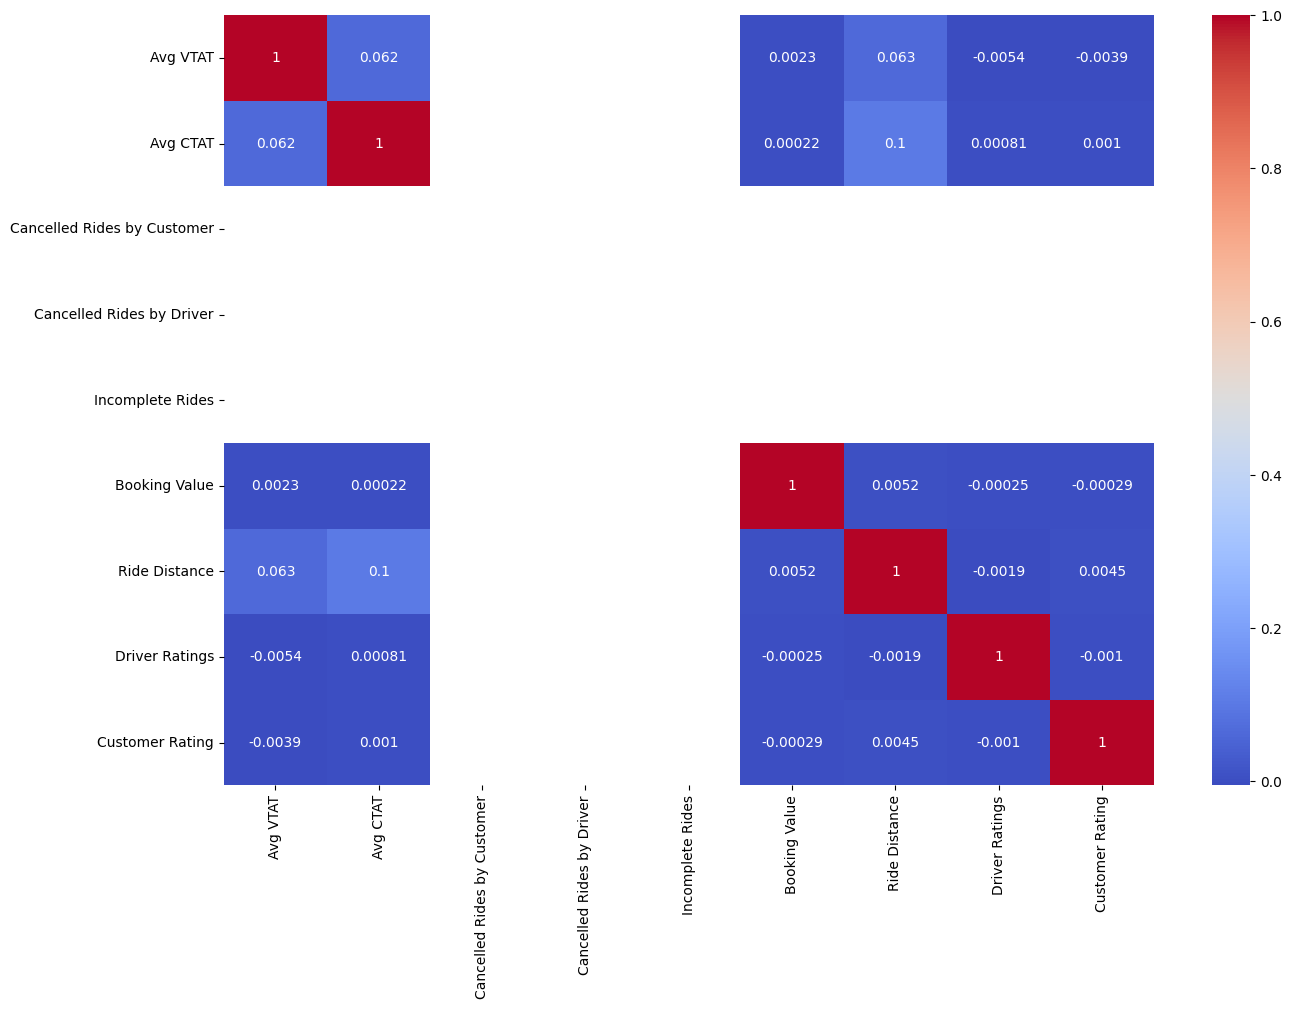

In [15]:
corr = df_uber.select_dtypes(include=np.number).corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

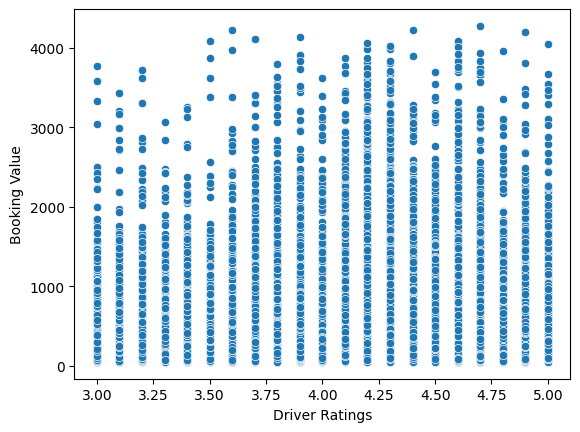

In [17]:
sns.scatterplot( data=df_uber,x="Driver Ratings",y="Booking Value")
plt.show()

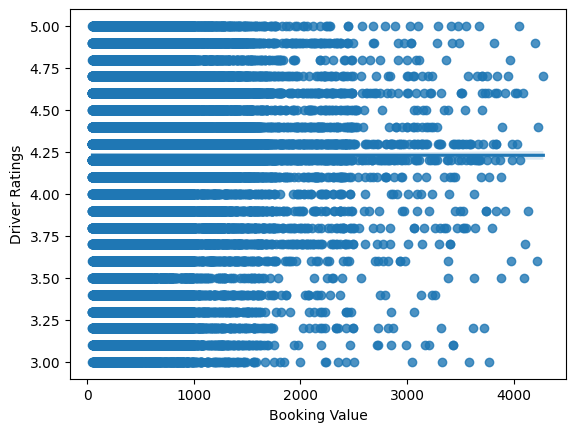

In [18]:
sns.regplot(x="Booking Value", y="Driver Ratings", data=df_uber)
plt.show()

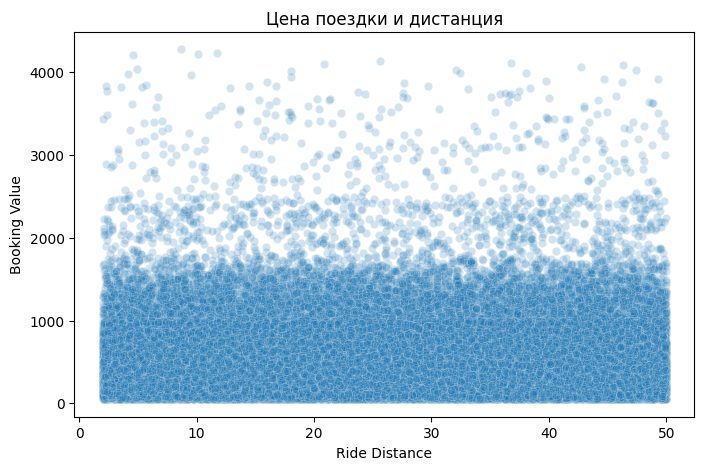

               Ride Distance  Booking Value
Ride Distance       1.000000       0.005668
Booking Value       0.005668       1.000000


In [24]:
# Проверяем: зависит ли цена от дистанции
df_done = df_uber[df_uber["Booking Status"] == "Completed"]

df_done = df_done.dropna(subset=["Ride Distance", "Booking Value"])
df_done = df_done[df_done["Ride Distance"] > 0]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_done, x="Ride Distance", y="Booking Value", alpha=0.2)
plt.title("Цена поездки и дистанция")
plt.show()

print(df_done[["Ride Distance", "Booking Value"]].corr())

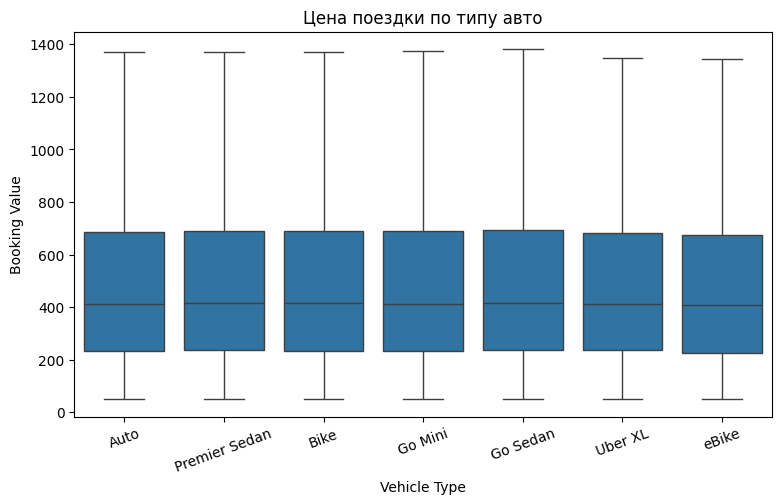

Vehicle Type
Go Sedan         417.0
Premier Sedan    417.0
Bike             415.0
Auto             413.0
Go Mini          412.0
Uber XL          411.0
eBike            409.0
Name: Booking Value, dtype: float64


In [25]:
# Проверяем: зависит ли цена от типа авто
df_type = df_uber[df_uber["Booking Status"] == "Completed"]
df_type = df_type.dropna(subset=["Booking Value", "Vehicle Type"])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_type, x="Vehicle Type", y="Booking Value", showfliers=False)
plt.xticks(rotation=20)
plt.title("Цена поездки по типу авто")
plt.show()

print(df_type.groupby("Vehicle Type")["Booking Value"].median().sort_values(ascending=False))

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_1728\2959635102.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_time["hour"] = pd.to_datetime(df_time["Time"]).dt.hour


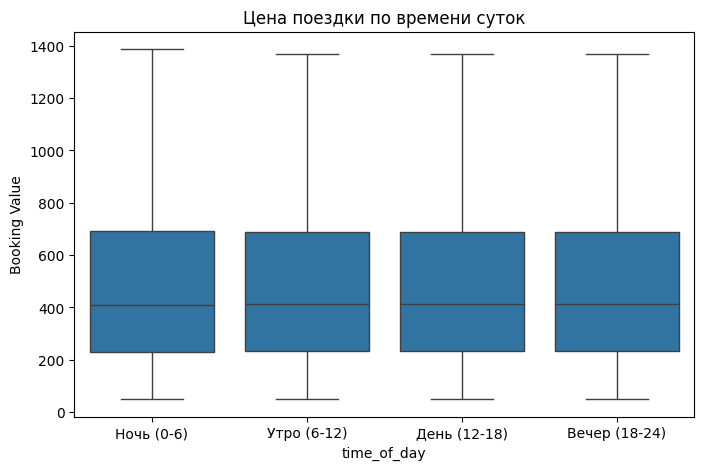

time_of_day
Вечер (18-24)    415.0
Утро (6-12)      414.0
День (12-18)     413.0
Ночь (0-6)       409.5
Name: Booking Value, dtype: float64

In [ ]:
# Проверяем: зависит ли цена от времени суток
df_time = df_uber[df_uber["Booking Status"] == "Completed"]
df_time = df_time.dropna(subset=["Booking Value", "Time"])

# Создаём столбец с часом
df_time["hour"] = pd.to_datetime(df_time["Time"]).dt.hour

# Определяем часть дня через цикл
time_of_day = []
for h in df_time["hour"]:
    if 6 <= h < 12:
        time_of_day.append("Утро (6-12)")
    elif 12 <= h < 18:
        time_of_day.append("День (12-18)")
    elif 18 <= h < 24:
        time_of_day.append("Вечер (18-24)")
    else:
        time_of_day.append("Ночь (0-6)")

df_time["time_of_day"] = time_of_day

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_time, x="time_of_day", y="Booking Value", showfliers=False,
            order=["Ночь (0-6)", "Утро (6-12)", "День (12-18)", "Вечер (18-24)"])
plt.title("Цена поездки по времени суток")
plt.show()

print(df_time.groupby("time_of_day")["Booking Value"].median().sort_values(ascending=False))

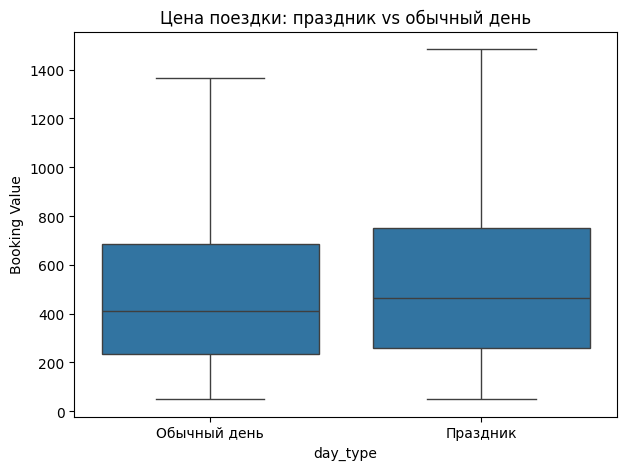

day_type
Обычный день    412.0
Праздник        466.0
Name: Booking Value, dtype: float64


In [30]:
# Проверяем: зависит ли цена от праздников (Индия 2024)

# Государственные праздники Индии 2024
india_holidays = [
    "2024-01-26",  # Republic Day
    "2024-03-25",  # Holi
    "2024-04-14",  # Dr. Ambedkar Jayanti
    "2024-04-17",  # Ram Navami
    "2024-04-21",  # Mahavir Jayanti
    "2024-05-23",  # Buddha Purnima
    "2024-08-15",  # Independence Day
    "2024-10-02",  # Gandhi Jayanti
    "2024-10-12",  # Dussehra
    "2024-11-01",  # Diwali
    "2024-11-15",  # Guru Nanak Jayanti
    "2024-12-25",  # Christmas
]

df_holiday = df_uber[df_uber["Booking Status"] == "Completed"]
df_holiday = df_holiday.dropna(subset=["Booking Value", "Date"])

df_holiday["Date"] = pd.to_datetime(df_holiday["Date"])
df_holiday["date_str"] = df_holiday["Date"].dt.strftime("%Y-%m-%d")

# Маркируем праздник или обычный день
is_holiday = []
for d in df_holiday["date_str"]:
    if d in india_holidays:
        is_holiday.append("Праздник")
    else:
        is_holiday.append("Обычный день")

df_holiday["day_type"] = is_holiday

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_holiday, x="day_type", y="Booking Value", showfliers=False)
plt.title("Цена поездки: праздник vs обычный день")
plt.show()

print(df_holiday.groupby("day_type")["Booking Value"].median())